# 1. Setup

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/NIT Colab Notebooks')

# # Copy the stuff from Drive to local Colab storage (Fast)
# !cp "/content/drive/MyDrive/NIT Colab Notebooks/data/hvoice-fake-voice.zip" "/content/"
# !mkdir -p "/content/4 Deep4SNet Model"
# !cp -r "/content/drive/MyDrive/NIT Colab Notebooks/4 Deep4SNet Model"/* "/content/4 Deep4SNet Model/"
# # Unzip it locally
# !mkdir -p /content/data/hvoice-fake-voice
# !unzip -qq -o /content/hvoice-fake-voice.zip -d /content/data/

# os.chdir('/content')
# # Plots thingy
# !rm -r plots
# !mkdir plots
# print("Current working directory:", os.getcwd())

!mkdir -p data
!mkdir -p "4 Deep4SNet Model"
!mkdir -p "5 attack outputs"
# Download the dataset and weights
!wget -q -O hvoice-fake-voice.zip "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/data/hvoice-fake-voice.zip"
!wget -q -O "4 Deep4SNet Model/model_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/model_Deep4SNet.h5"
!wget -q -O "4 Deep4SNet Model/weights_Deep4SNet.h5" "https://raw.githubusercontent.com/msr8/NIT/refs/heads/main/4%20Deep4SNet%20Model/weights_Deep4SNet.h5"
# Unzip it locally
!unzip -qq -o hvoice-fake-voice.zip -d data
!rm hvoice-fake-voice.zip

# # Plot stuff
# !rm plots/7*
# !mkdir -p plots

In [2]:
# !pip install tensorflow opencv-python-headless matplotlib numpy
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # quiet TF logs

import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Input, Dense, Conv2D, Reshape, Flatten, Dropout, LeakyReLU, BatchNormalization, UpSampling2D, MaxPooling2D
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("GPU       :", tf.config.list_physical_devices("GPU") or "none (CPU)")

SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.20.0
Keras     : 3.13.2
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# 2. Configuration

In [3]:

DATA_ROOT = 'data/hvoice-fake-voice'
MODEL_H5 = '4 Deep4SNet Model/model_Deep4SNet.h5'
WEIGHTS_H5 = '4 Deep4SNet Model/weights_Deep4SNet.h5'

IMG = 150
LATENT_DIM = 100

ATTACK1_STEPS_PER_EPOCH = 64   # noise batches per epoch
BATCH = 32
SAMPLE_EVERY = 50               # save a sample grid every N epochs

OUTPUT_DIR = '5 attack outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Clean up the output directory
for f in glob.glob(os.path.join(OUTPUT_DIR, "*")):
    os.remove(f)

In [4]:
def build_deep4snet():
    # Deep4SNet, reconstructed from the saved model config (Keras-3 safe)
    model = keras.Sequential([
        Input((IMG, IMG, 3)),

        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ], name="Deep4SNet")
    return model

victim = build_deep4snet()
victim.load_weights(WEIGHTS_H5)   # real trained weights
victim.trainable = False          # frozen: it is the fixed adversary's target
victim.summary()

I0000 00:00:1784882812.754045     154 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784882812.757150     154 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Deep4SNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,513 (4.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,212,513 (4.63 MB)

# 3. Data & preprocessing

Deep4SNet was trained on raw `cv2` pixels in 0–255 (its inference does no `/255`). Our generators emit sigmoid outputs in [0,1] (stable to train). We bridge the two with a fixed `Rescaling(255.)` layer right before the victim so the frozen detector always sees inputs on its native scale. `cv2.imread` returns BGR, so we keep BGR everywhere for consistency with the original model and only swap to RGB for display

  Training_original        2020
  Training_fake            2088
  Validation_original       864
  Validation_fake           864


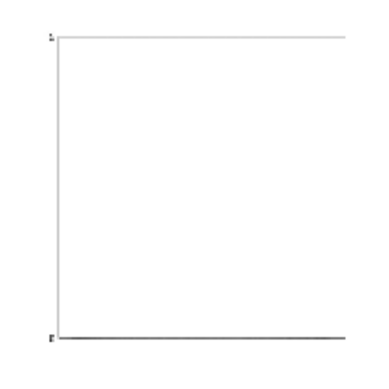

In [5]:
def list_images(folder):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
    files = []
    for e in exts:
        files += glob.glob(os.path.join(DATA_ROOT, folder, e))
    return sorted(files)


def load_batch01(paths):
    # Load images as BGR, resize to 150x150, scale to [0,1] -> (N,150,150,3)
    out = np.empty((len(paths), IMG, IMG, 3), dtype="float32")
    for i, p in enumerate(paths):
        img = cv2.imread(p)
        img = cv2.resize(img, (IMG, IMG))
        out[i] = img.astype("float32") / 255.0
    return out


def to_victim(x01):
    # [0,1] -> native 0-255 scale the frozen Deep4SNet expects
    return x01 * 255.0


def show_grid(imgs01, title="", n=8, save=None):
    n = min(n, len(imgs01))
    plt.figure(figsize=(2*n, 2.2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        rgb = cv2.cvtColor((imgs01[i]*255).astype("uint8"), cv2.COLOR_BGR2RGB)
        plt.imshow(rgb); plt.axis("off")
    plt.suptitle(title); plt.tight_layout()
    if save: plt.savefig(save, dpi=90, bbox_inches="tight")
    plt.show()


def build_empty_template(folder="Training_original", n=400):
    paths = list_images(folder)[:n]
    imgs  = load_batch01(paths)                 # (N,150,150,3) in [0,1]
    tmpl  = imgs.max(axis=0)                    # brightest pixel across set
    gray  = tmpl.mean(-1, keepdims=True)        # kill any color tint
    return np.repeat(gray, 3, axis=-1).astype("float32")   # (150,150,3), R=G=B


for d in ["Training_original", "Training_fake", "Validation_original", "Validation_fake"]:
    p = os.path.join(DATA_ROOT, d)
    print(f"  {d:22s} {len(os.listdir(p)) if os.path.isdir(p) else 'MISSING':>6}")

TEMPLATE    = build_empty_template(n=2000)
TEMPLATE_TF = tf.constant(TEMPLATE[None], dtype=tf.float32)   # (1,150,150,3)

# plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor((TEMPLATE*255).astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.savefig('plots/8.1 template.png', dpi=300, bbox_inches="tight")
plt.show()

# 4. Sanity check: the victim works before we break it

I0000 00:00:1784882824.169827     230 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


              precision    recall  f1-score   support

        Real       0.88      0.91      0.89       864
        Fake       0.90      0.88      0.89       864

    accuracy                           0.89      1728
   macro avg       0.89      0.89      0.89      1728
weighted avg       0.89      0.89      0.89      1728



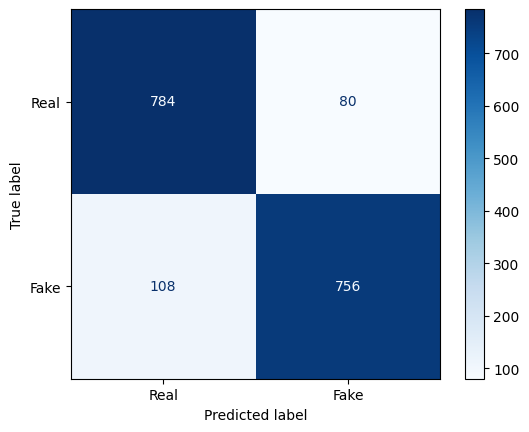

In [6]:
def victim_real_prob(x01, bs=64):
    return victim.predict(to_victim(x01), batch_size=bs, verbose=0).ravel()


preds = []
Ys    = []
for d in ["Validation_original", "Validation_fake"]:
    paths = list_images(d)
    X = load_batch01(paths)
    pred = victim.predict(to_victim(X), batch_size=64, verbose=0).ravel()
    preds.append((pred > 0.5).astype(int))
    Ys.append( np.ones(len(pred), dtype=int) if d.endswith("original") else np.zeros(len(pred), dtype=int) )

pred = np.concatenate(preds)
Y    = np.concatenate(Ys)

cm = confusion_matrix(Y, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap=plt.cm.Blues)

print(classification_report(Y, pred, target_names=["Real", "Fake"]))
plt.savefig('plots/8.2 confusion matrix.png', dpi=300, bbox_inches="tight")
plt.show()

# 5. Training the generator to synthesize real histograms from noise

A generator $G_1(z)$ maps a latent vector to a 150×150×3 image and is trained so the frozen Deep4SNet labels it as real

| Component | Weight | Goal |
|-----------|--------|------|
| adversarial ($V$ = frozen victim) | $\alpha = 0.3$ | frozen Deep4SNet says "real" |
| realism ($D_\text{real}$) | $\beta = 1.0$ | output is indistinguishable from a genuine histogram |

$$\text{Loss}_G = (0.3 \times \text{BCE}\big(1, \; V(G(z))\big)) \; + \; \beta \cdot \text{BCE}\big(1, \; D_{\text{real}}(G(z))\big)$$



In [7]:
class GrayToRGB(layers.Layer):
    '''Tile a 1-channel image to 3 channels so R=G=B (no colored pixels possible)'''
    def call(self, x):
        return tf.repeat(x, 3, axis=-1)


RESID_EPS = 1.0   # how far the generator may move each template pixel (tanh residual in [-1,1])

class ResidualOverTemplate(layers.Layer):
    '''Compose the output as a bounded grayscale residual over the fixed histogram template, so every sample is on-manifold by construction: white canvas + axes (from the template) plus a learned spike. This is what keeps the generator from drifting into non-histogram garbage.

    Input (B,150,150,1) in [-1,1] -> (B,150,150,3)'''
    def __init__(self, template, eps=1.0, **kw):
        super().__init__(**kw)
        self.template = tf.constant(template, dtype=tf.float32)   # (1,150,150,3), grayscale
        self.eps = float(eps)
    def call(self, r):
        r3 = tf.repeat(r, 3, axis=-1)                             # grayscale residual, R=G=B
        return tf.clip_by_value(self.template + self.eps * r3, 0.0, 1.0)


gen1 = keras.Sequential([
    keras.Input((LATENT_DIM,)),

    Dense(15*15*128),
    layers.LeakyReLU(0.2),
    layers.Reshape((15, 15, 128)),

    layers.Conv2DTranspose(64, 5, strides=2, padding="same"),
    layers.LeakyReLU(0.2),
    layers.Conv2DTranspose(32, 5, strides=5, padding="same"),
    layers.LeakyReLU(0.2),
    layers.Conv2DTranspose(32, 5, strides=1, padding="same"),
    layers.LeakyReLU(0.2),

    # signed grayscale residual in [-1,1]. tanh starts near 0, so the generator begins exactly on the histogram template and only has to learn the spike.
    layers.Conv2D(1, 5, strides=1, padding="same", activation="tanh", name="ink"),
    ResidualOverTemplate(TEMPLATE_TF, eps=RESID_EPS),   # img = clip(template + eps*residual, 0,1)
], name="Generator_Attack1")
gen1.summary()

assert gen1.output_shape[1:] == (IMG, IMG, 3), gen1.output_shape


combined1 = keras.Sequential([
    gen1,
    layers.Rescaling(255.0),
    victim,
], name="Combined_Attack1")
combined1.compile(optimizer=keras.optimizers.Adam(1e-4), loss="binary_crossentropy")
combined1.summary()


feat_in = keras.Input((IMG, IMG, 3))
x = feat_in
for layer in victim.layers[:-2]:        # stop after Dense(64), skip Dropout + final Dense(1)
    x = layer(x)
feat_model = keras.Model(feat_in, x, name="VictimFeats")
feat_model.trainable = False
feat_model.summary()                    # confirm output shape is (None, 64)


# Trainable realism discriminator. This is the piece the frozen victim structurally cannot provide: a gradient for "does this look like a real histogram". Trained as a normal GAN discriminator (real originals vs generator output) alongside gen1
D_real = keras.Sequential([
    keras.Input((IMG, IMG, 3)),
    Conv2D(32,  4, strides=2, padding="same"), layers.LeakyReLU(0.2),
    Conv2D(64,  4, strides=2, padding="same"), layers.LeakyReLU(0.2),
    Conv2D(128, 4, strides=2, padding="same"), layers.LeakyReLU(0.2),
    Flatten(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
], name="D_real")
D_real.summary()


Model: "Generator_Attack1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 28800)          │     2,908,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 30, 30, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 150, 150, 32)   │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 150, 150, 32)   │        25,632 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ink (Conv2D)                    │ (None, 150, 150, 1)    │           801 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_over_template          │ (None, 150, 150, 3)    │             0 │
│ (ResidualOverTemplate)          │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,191,329 (12.17 MB)

 Trainable params: 3,191,329 (12.17 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "D_real"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 38, 38, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 19, 19, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46208)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46208)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        46,209 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,809 (827.38 KB)

 Trainable params: 211,809 (827.38 KB)

 Non-trainable params: 0 (0.00 B)

caching 2020 real histograms into RAM


2026-07-24 08:47:33.331952: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-24 08:47:33.634531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


ep    1  g=2.4797  adv=3.7728  real=1.3478  d=0.8332  ASR=100.00%


2026-07-24 08:47:37.195754: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-24 08:47:37.496533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


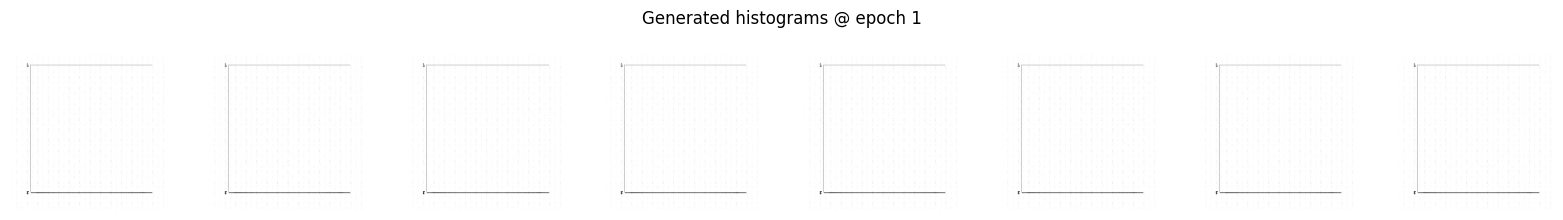

ep    5  g=3.5881  adv=0.0003  real=3.5881  d=0.0899  ASR=100.00%
ep   10  g=3.7196  adv=0.0000  real=3.7196  d=0.4218  ASR=100.00%


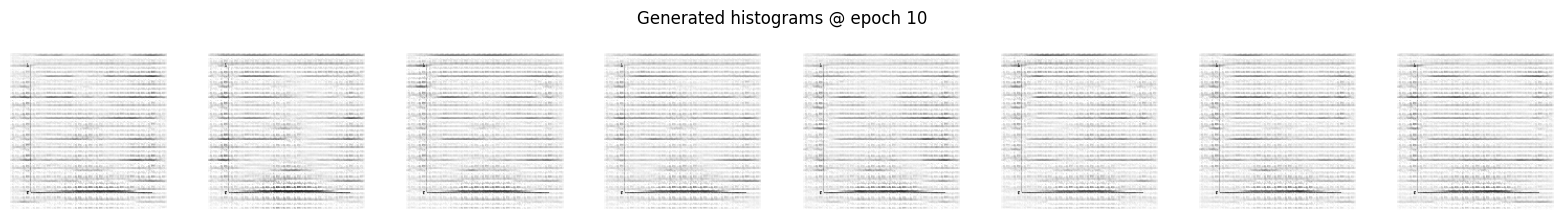

ep   15  g=2.7728  adv=0.1660  real=2.7230  d=0.4281  ASR=100.00%
ep   20  g=3.4844  adv=0.0880  real=3.4580  d=0.1264  ASR=100.00%


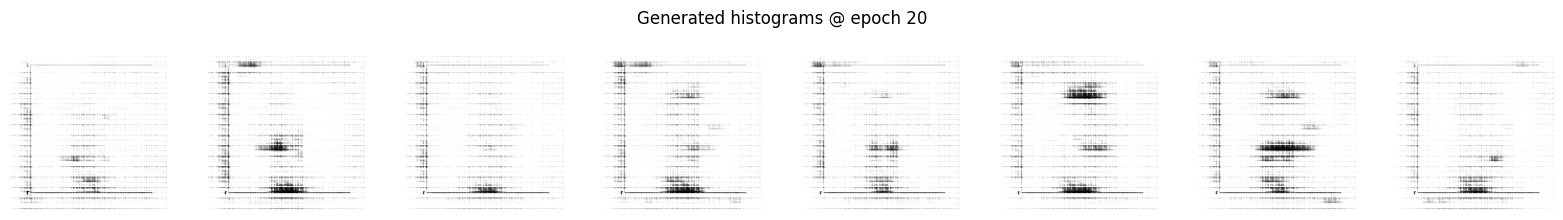

ep   25  g=3.5125  adv=0.4053  real=3.3909  d=0.1340  ASR=100.00%
ep   30  g=3.7806  adv=0.1588  real=3.7329  d=0.1175  ASR=100.00%


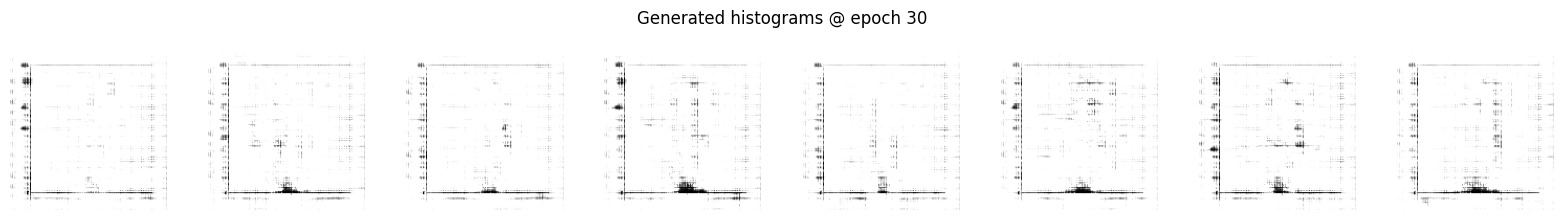

ep   35  g=3.9639  adv=0.8469  real=3.7099  d=0.1506  ASR=100.00%
ep   40  g=4.0895  adv=0.2723  real=4.0078  d=0.1187  ASR=100.00%


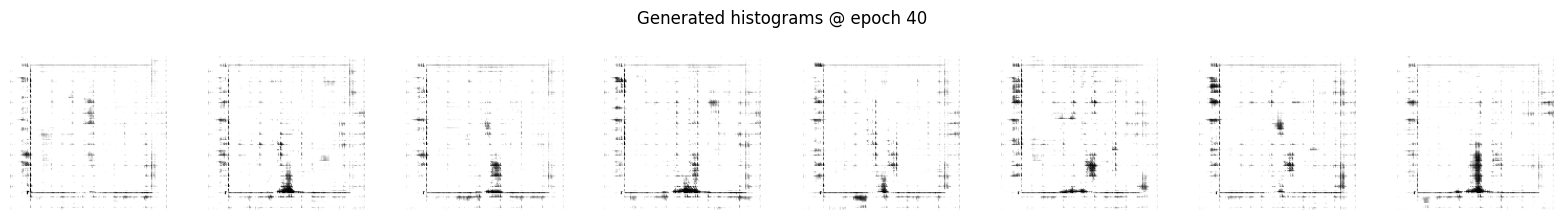

ep   45  g=3.8027  adv=0.7350  real=3.5822  d=0.1392  ASR=100.00%
ep   50  g=3.9927  adv=0.0664  real=3.9728  d=0.1105  ASR=100.00%


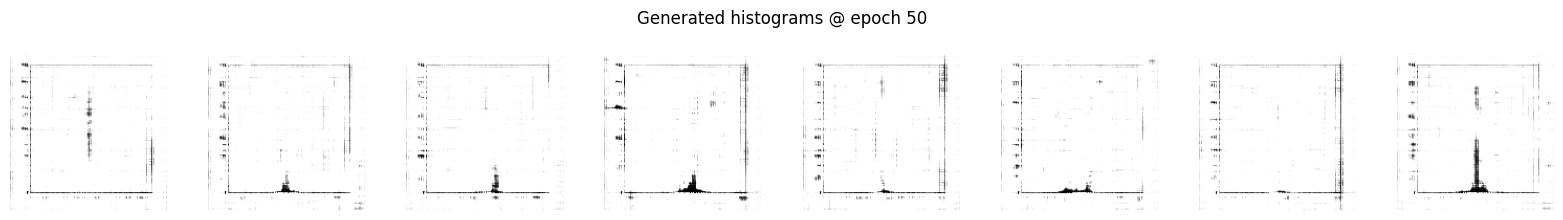

ep   55  g=4.5303  adv=0.1359  real=4.4896  d=0.0936  ASR=100.00%
ep   60  g=4.3588  adv=0.0832  real=4.3339  d=0.0781  ASR=100.00%


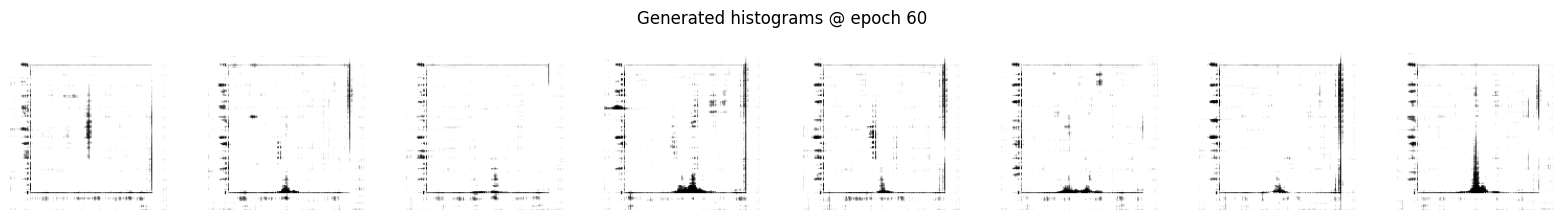

ep   65  g=4.4748  adv=0.2330  real=4.4049  d=0.0861  ASR=100.00%
ep   70  g=4.8456  adv=0.7396  real=4.6238  d=0.0803  ASR=100.00%


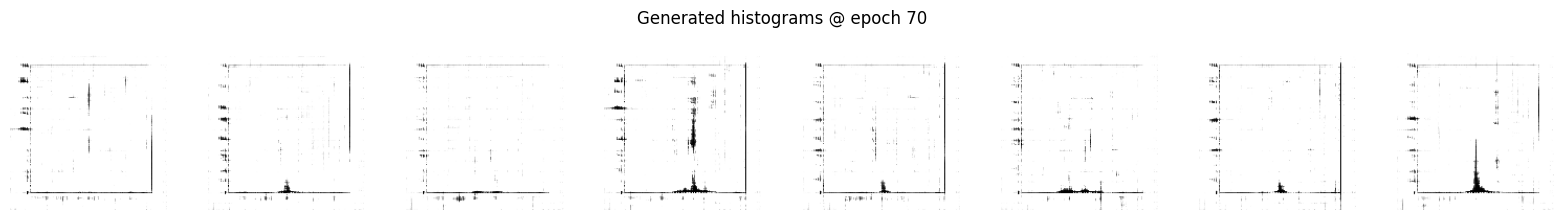

ep   75  g=4.6299  adv=0.3908  real=4.5127  d=0.0900  ASR=100.00%
ep   80  g=4.6995  adv=0.1747  real=4.6471  d=0.0590  ASR=100.00%


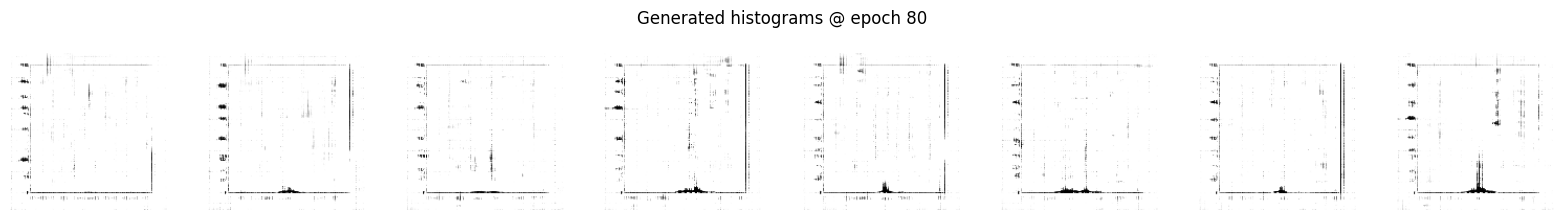

ep   85  g=4.6416  adv=0.2324  real=4.5719  d=0.0617  ASR=100.00%
ep   90  g=5.0013  adv=0.5818  real=4.8267  d=0.0697  ASR=100.00%


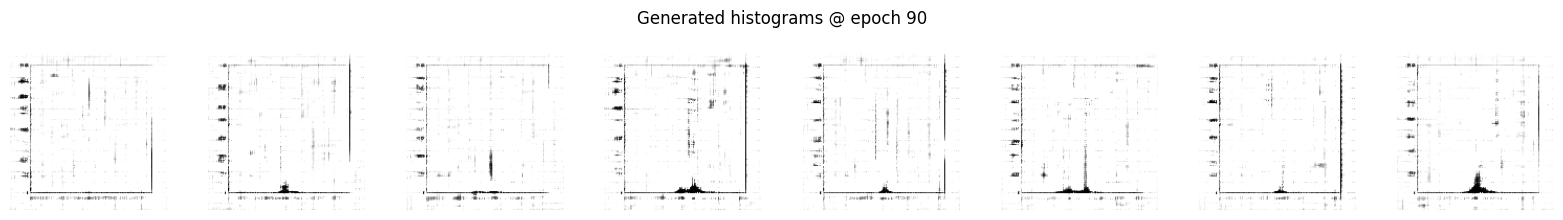

ep   95  g=4.9265  adv=0.3624  real=4.8178  d=0.0571  ASR=100.00%
ep  100  g=5.0594  adv=0.3662  real=4.9495  d=0.0468  ASR=100.00%


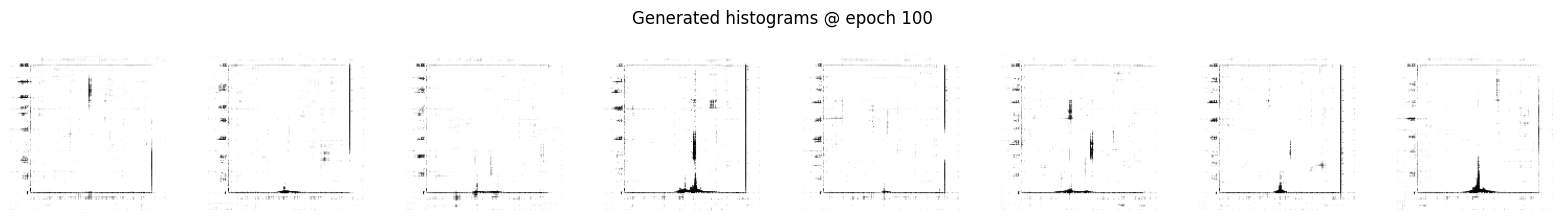

ep  105  g=4.8697  adv=0.0000  real=4.8697  d=0.0766  ASR=100.00%
ep  110  g=5.3677  adv=0.3394  real=5.2658  d=0.0606  ASR=100.00%


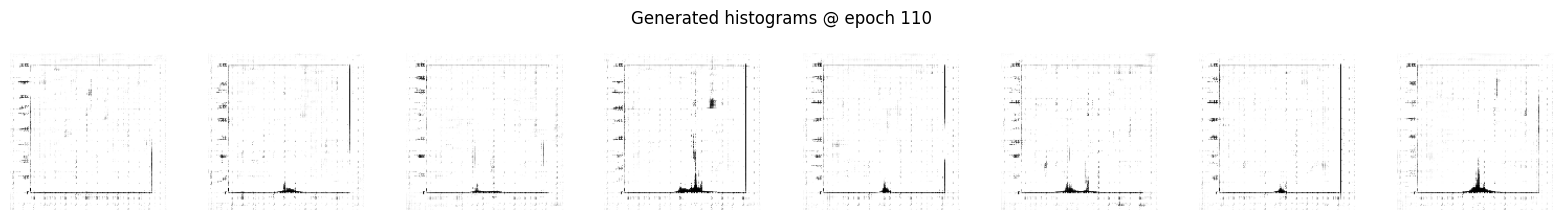

ep  115  g=5.2441  adv=0.0000  real=5.2441  d=0.0412  ASR=100.00%
ep  120  g=5.3457  adv=0.4106  real=5.2226  d=0.0547  ASR=100.00%


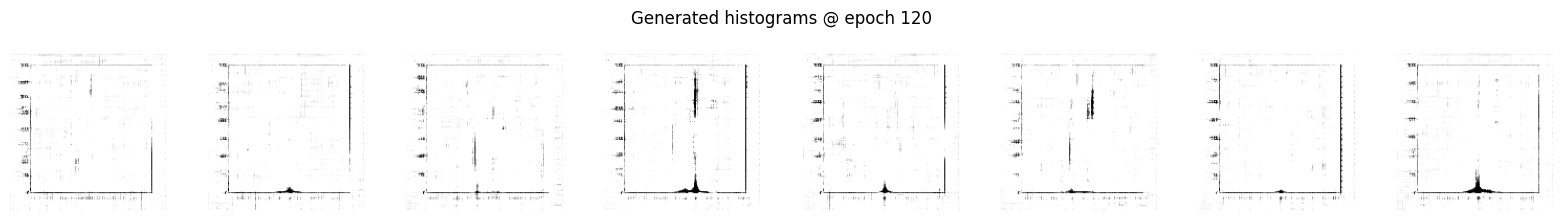

ep  125  g=5.0060  adv=0.0255  real=4.9983  d=0.0549  ASR=100.00%
ep  130  g=4.8326  adv=0.0944  real=4.8043  d=0.0702  ASR=100.00%


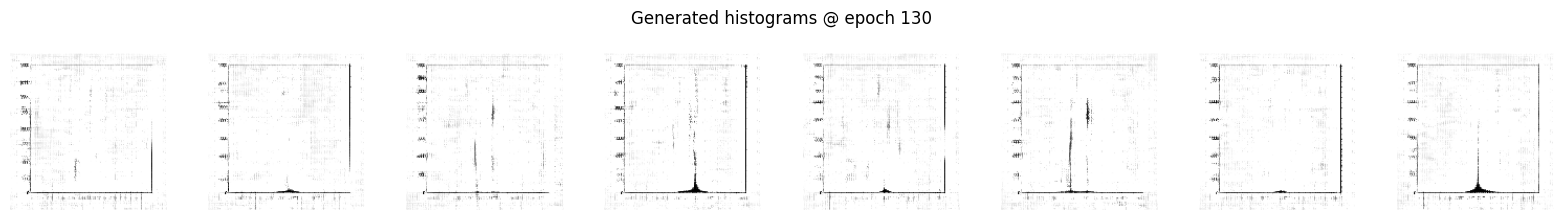

ep  135  g=4.8428  adv=0.1237  real=4.8057  d=0.0869  ASR=100.00%
ep  140  g=4.8638  adv=0.5647  real=4.6944  d=0.0872  ASR=100.00%


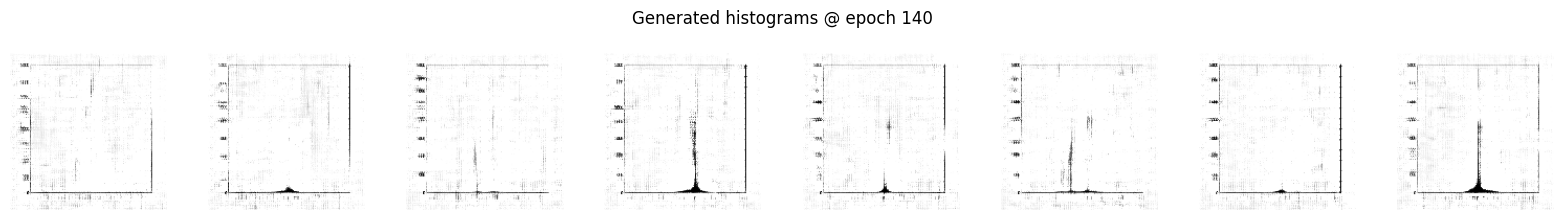

ep  145  g=4.5276  adv=0.1504  real=4.4825  d=0.1143  ASR=100.00%
ep  150  g=4.9320  adv=0.2815  real=4.8476  d=0.0987  ASR=100.00%


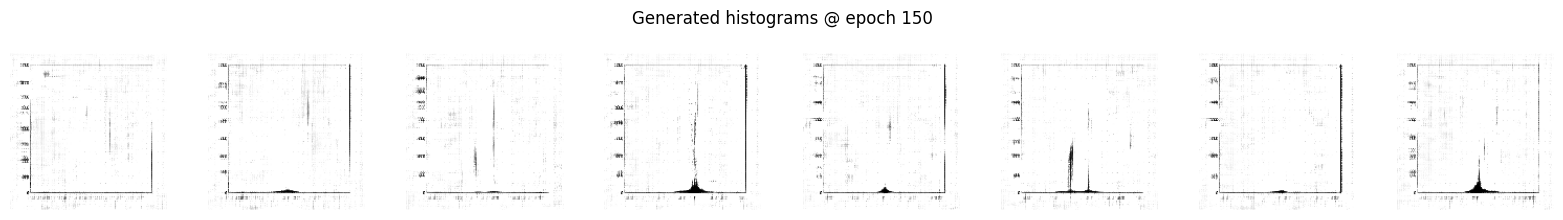

ep  155  g=4.8468  adv=0.1598  real=4.7989  d=0.0775  ASR=100.00%


In [ ]:
# cache a pool of real histogram paths once
# real_paths = list_images("Training_original")
# def sample_real_batch(n):
#     idx = np.random.choice(len(real_paths), n, replace=False)
#     return load_batch01([real_paths[i] for i in idx])

ATTACK1_EPOCHS = 400


real_paths = list_images("Training_original")
print(f"caching {len(real_paths)} real histograms into RAM")
_REAL_CACHE = load_batch01(real_paths)   # decoded once
def sample_real_batch(n):
    idx = np.random.choice(len(_REAL_CACHE), n, replace=False)
    return _REAL_CACHE[idx]



def sample_z(n):
    return np.random.normal(0, 1, (n, LATENT_DIM)).astype("float32")

def asr_attack1(n=100, repeats=100, thr=0.5):
    # Attack success rate: fraction of generated histograms classified Real, averaged over repeats
    rates = []
    for _ in range(repeats):
        g = gen1.predict(sample_z(n), verbose=0)
        rates.append((victim_real_prob(g) > thr).mean())
    return float(np.mean(rates)), float(np.std(rates))



# Fooling this frozen victim is the CHEAP objective (it's blind to histogram realism), so realism dominates and the adversarial term stays small. ASR comes almost for free
ALPHA_ADV = 0.3     # weight: "victim says Real"
BETA_REAL = 1.0     # weight: "D_real says real histogram"

opt_g    = keras.optimizers.Adam(1e-4)
opt_d    = keras.optimizers.Adam(1e-4)
bce_loss = keras.losses.BinaryCrossentropy()

def _gray3(x):
    # Feed D_real grayscale reals so it judges spike STRUCTURE, not the faint colour of the dataset's axis ticks (which the grayscale generator can't emit -> trivial tell)
    g = tf.reduce_mean(x, axis=-1, keepdims=True)
    return tf.repeat(g, 3, axis=-1)

@tf.function
def train_step(z, real_batch):
    # 1) train realism discriminator: real originals vs generated
    with tf.GradientTape() as td:
        gen_imgs   = gen1(z, training=True)
        d_real_out = D_real(_gray3(real_batch), training=True)
        d_fake_out = D_real(gen_imgs,           training=True)
        d_loss = bce_loss(tf.ones_like(d_real_out),  d_real_out) \
               + bce_loss(tf.zeros_like(d_fake_out), d_fake_out)
    opt_d.apply_gradients(zip(td.gradient(d_loss, D_real.trainable_variables),
                              D_real.trainable_variables))

    # 2) Train generator: fool the frozen victim + look real to D_real
    with tf.GradientTape() as tg:
        gen_imgs = gen1(z, training=True)
        v_pred = victim(gen_imgs * 255.0, training=False)   # frozen -> adversarial term
        r_pred = D_real(gen_imgs, training=True)            # realism term
        adv  = bce_loss(tf.ones_like(v_pred), v_pred)
        real = bce_loss(tf.ones_like(r_pred), r_pred)
        g_loss = ALPHA_ADV * adv + BETA_REAL * real
    opt_g.apply_gradients(zip(tg.gradient(g_loss, gen1.trainable_variables), gen1.trainable_variables))
    return g_loss, adv, real, d_loss

fixed_z = sample_z(8)
hist1 = {"epoch": [], "g_loss": [], "adv": [], "real": [], "d_loss": [], "asr": []}

for ep in range(1, ATTACK1_EPOCHS + 1):
    ep_g = ep_adv = ep_real = ep_d = 0.0
    for _ in range(ATTACK1_STEPS_PER_EPOCH):
        z    = tf.constant(sample_z(BATCH))
        real = tf.constant(sample_real_batch(BATCH))
        g, a, r, d = train_step(z, real)
        ep_g += float(g); ep_adv += float(a); ep_real += float(r); ep_d += float(d)
    ep_g /= ATTACK1_STEPS_PER_EPOCH; ep_adv /= ATTACK1_STEPS_PER_EPOCH
    ep_real /= ATTACK1_STEPS_PER_EPOCH; ep_d /= ATTACK1_STEPS_PER_EPOCH

    if ep % 5 == 0 or ep == 1 or ep == ATTACK1_EPOCHS:
        g   = gen1.predict(sample_z(100), verbose=0)
        asr = (victim_real_prob(g) > 0.5).mean()
        hist1["epoch"].append(ep); hist1["g_loss"].append(ep_g)
        hist1["adv"].append(ep_adv); hist1["real"].append(ep_real)
        hist1["d_loss"].append(ep_d); hist1["asr"].append(asr)
        print(f"ep {ep:4d}  g={ep_g:.4f}  adv={ep_adv:.4f}  real={ep_real:.4f}  d={ep_d:.4f}  ASR={asr:.2%}")
    if ep % 10 == 0 or ep == 1:
        show_grid(gen1.predict(fixed_z, verbose=0),
                  f"Generated histograms @ epoch {ep}",
                  save=os.path.join(OUTPUT_DIR, f"attack1_epoch_{ep:04d}.png"))


In [ ]:
# Save the generator weights as this takes a SHIT ton of time to train
gen1.save_weights(os.path.join(OUTPUT_DIR, "generator.weights.h5"))

In [ ]:
import numpy as np
tests = {
    "uniform white (255)":  np.ones ((8,150,150,3), "float32"),
    "uniform black (0)":    np.zeros((8,150,150,3), "float32"),
    "uniform mid (~127)":   np.full ((8,150,150,3), 0.5, "float32"),
    "uniform [0,1] noise":  np.random.uniform(0,1, (8,150,150,3)).astype("float32"),
    "gaussian around .5":   np.clip(np.random.normal(.5,.2,(8,150,150,3)),0,1).astype("float32"),
    "fresh gen1 output":    gen1.predict(sample_z(8), verbose=0),
    "a real histogram":     load_batch01(list_images("Training_original")[:8]),
    "a fake histogram":     load_batch01(list_images("Training_fake")[:8]),
}
for name, x in tests.items():
    p = victim.predict(to_victim(x), verbose=0).ravel()
    print(f"{name:25s}  P(Real)={p.mean():.4f} ± {p.std():.4f}")

# 6. Evaluation

In [ ]:
# ============================ Attack 1 — evaluation ============================
mean_asr, std_asr = asr_attack1(n=100, repeats=100)
print(f"Attack 1 success rate (100x100): {mean_asr:.2%} +/- {std_asr:.2%}")
print(f"=> Deep4SNet accuracy on the attack set: {1-mean_asr:.2%}  (paper: 98.5% -> ~0.08%)")

ep = hist1["epoch"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (a) attack success rate over training
ax[0].plot(ep, [a*100 for a in hist1["asr"]], marker=".", color="crimson")
ax[0].axhline(100, ls="--", lw=.8, color="grey")
ax[0].set_title("Attack success rate")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("ASR (%)")
ax[0].set_ylim(-2, 105)

# (b) generator objectives: realism should carry the load, adversarial stays tiny
ax[1].plot(ep, hist1["adv"],    marker=".", label=r"adv  ($\alpha$=0.3)")
ax[1].plot(ep, hist1["real"],   marker=".", label=r"real ($\beta$=1.0)")
ax[1].plot(ep, hist1["g_loss"], marker=".", label="g_loss (total)", color="black", lw=1)
ax[1].set_title("Generator loss components")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("BCE")
ax[1].legend()

# (c) realism discriminator — healthy GAN sits near 2·ln2 ≈ 1.386 (neither net winning)
ax[2].plot(ep, hist1["d_loss"], marker=".", color="teal")
ax[2].axhline(2*np.log(2), ls="--", lw=.8, color="grey", label="equilibrium 2·ln2 ≈ 1.386")
ax[2].set_title("Realism discriminator (D_real) loss")
ax[2].set_xlabel("epoch")
ax[2].set_ylabel("BCE")
ax[2].legend()

plt.tight_layout()
plt.savefig('plots/8.3 Training curves.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
from IPython.display import FileLink
FileLink('plots.zip')

In [ ]:
# FOR KAGGLE
import shutil
shutil.make_archive('/kaggle/working/5 attack outputs', 'zip', '/kaggle/working/plot')
from IPython.display import FileLink
FileLink('plots.zip')